# Telco Customer Churn - Exploratory Data Analysis
## Objective
This notebook explores the IBM Telco Customer Churn dataset to understand why customers leave and which factors predict churn.
## Dataset
- 7043 customers, 21 features
- Target variable: Churn (Yes/No)
- Source: IBM Sample Dataset via Kaggle


### 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns',50)


### 2. Data Loading

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")



Shape: (7043, 21)


### 3. Data Inspection

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


**Key observation**: TotalCharges column is stored as object (text) instead of 
float despite containing numeric values. This requires fixing before analysis.

In [6]:
print("Null values per column ")
print(df.isnull().sum())
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")

Null values per column 
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total duplicate rows: 0


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Nulls in TotalCharges after fix: {df['TotalCharges'].isnull().sum()}")
df.dropna(subset=['TotalCharges'], inplace=True)
print(f"Shape after dropping bad rows: {df.shape}")

Nulls in TotalCharges after fix: 11
Shape after dropping bad rows: (7032, 21)


Converted TotalCharges to numeric. Found 11 rows with whitespace values 
which were dropped. Final dataset shape: (7032, 21).

In [8]:
df.to_csv('../data/raw/telco_churn_cleaned.csv', index=False)
print("Cleaned CSV saved to data/raw/telco_churn_cleaned.csv")

Cleaned CSV saved to data/raw/telco_churn_cleaned.csv


### 4. Exploratory Analysis
#### 4.1 Churn Distribution

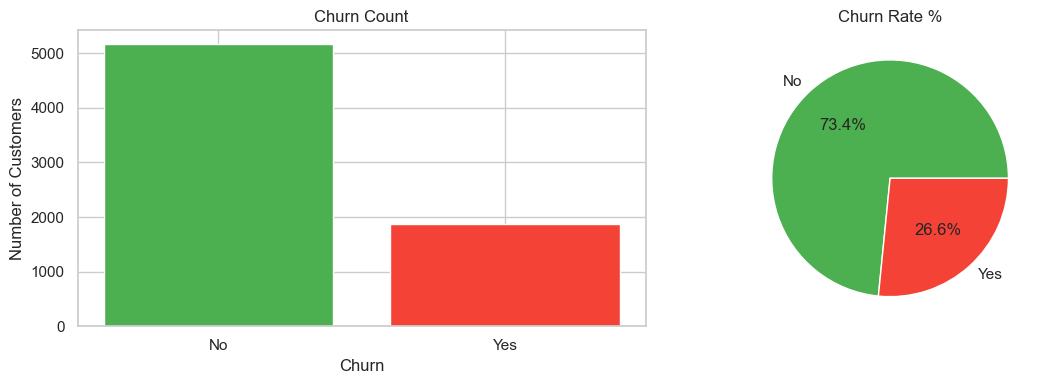

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, 
            color=['#4CAF50', '#F44336'])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')

churn_pct = df['Churn'].value_counts(normalize=True) * 100
axes[1].pie(churn_pct.values, labels=churn_pct.index,
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'])
axes[1].set_title('Churn Rate %')

plt.tight_layout()
plt.show()

**Finding:** Dataset is imbalanced 73.4% customers did not churn vs 26.6% who churned. 
This imbalance must be handled during model training to avoid biased predictions.

#### 4.2 Numeric Feature Distributions by Churn

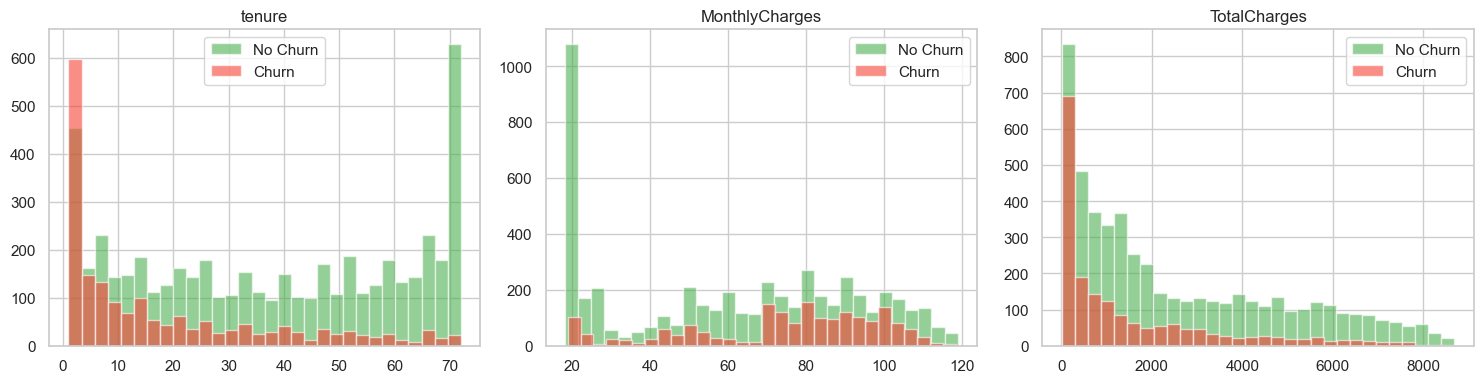

In [10]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    df[df['Churn']=='No'][col].hist(ax=axes[i], alpha=0.6, 
                                     label='No Churn', bins=30, color='#4CAF50')
    df[df['Churn']=='Yes'][col].hist(ax=axes[i], alpha=0.6, 
                                      label='Churn', bins=30, color='#F44336')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

**Finding:** Churned customers have significantly lower tenure concentrated 
in first 12 months. They also tend to have higher monthly charges. 
TotalCharges mirrors the tenure pattern as expected.

#### 4.3 Churn Rate by Categorical Features

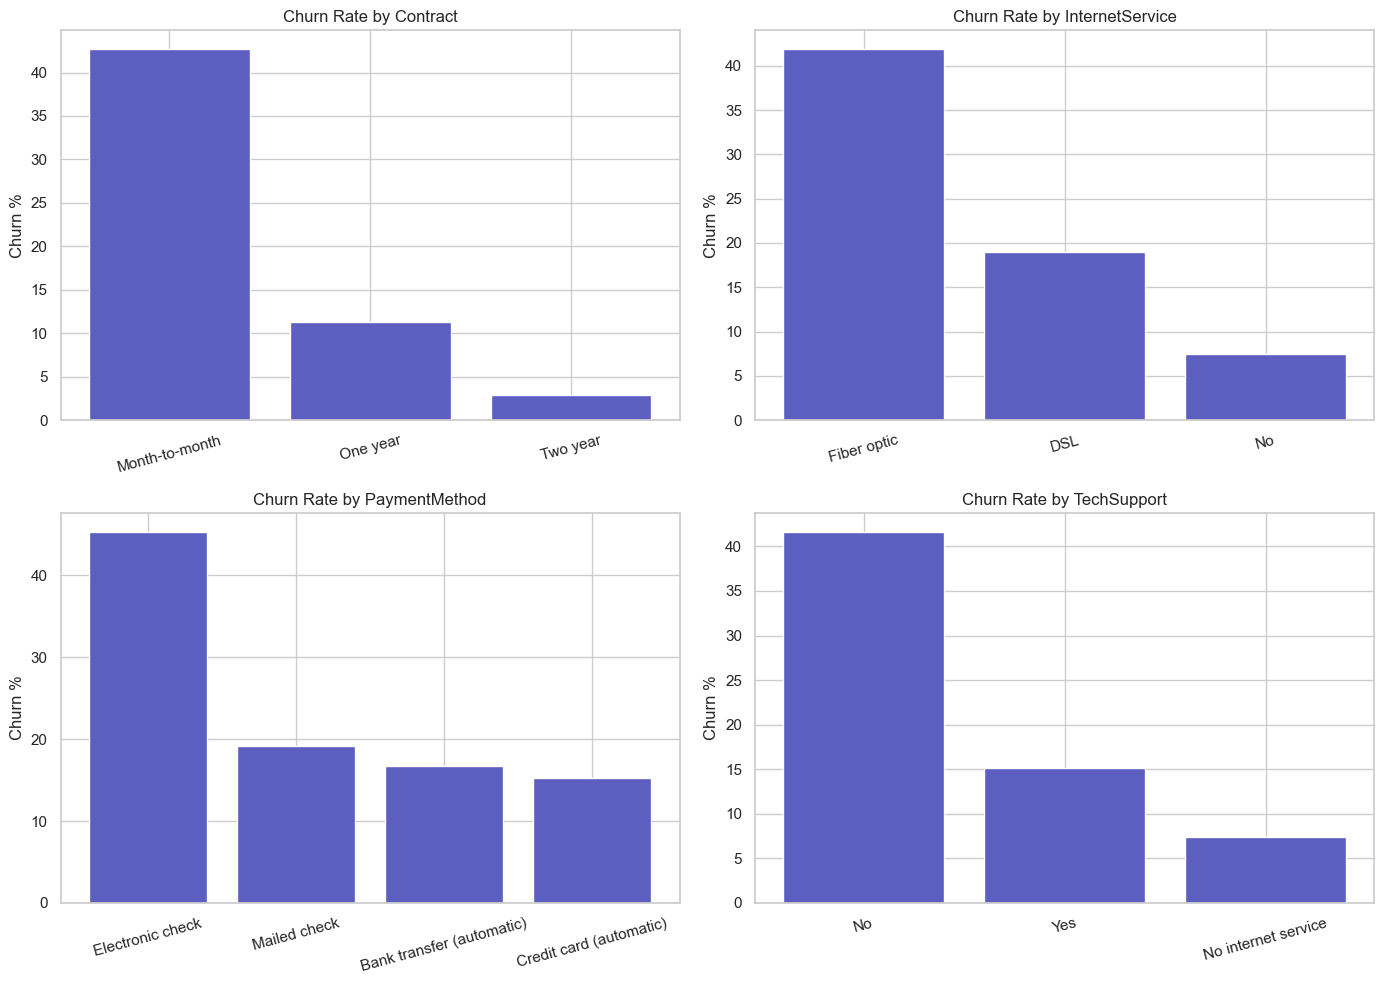

In [11]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).sort_values(ascending=False)
    
    axes[i].bar(churn_rate.index, churn_rate.values, color="#5C5EC0")
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn %')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Finding:** Contract type is the strongest categorical predictor. 
Month-to-month customers churn at 42% vs only 3% for two-year contracts. 
Fiber optic internet and electronic check payment also show elevated churn.

#### 4.4 Correlation Analysis

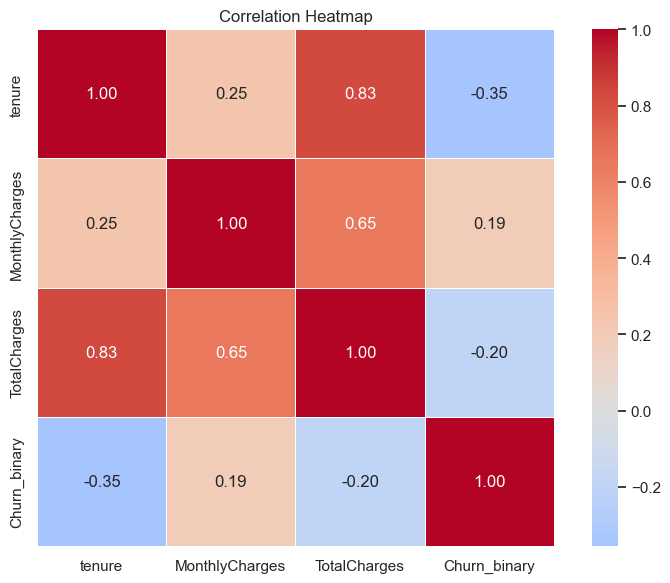

In [12]:
df_corr = df.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)

num_df = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']]
corr_matrix = num_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Finding:** Tenure has the strongest negative correlation with churn (-0.35). 
TotalCharges and tenure are highly correlated (0.83) suggesting redundancy.
TotalCharges may be dropped during feature selection.

### 5. Key Business Insights

1. **Churn rate is 26.6%** — dataset is imbalanced, requires handling during modeling
2. **New customers churn most** — highest risk in first 12 months of tenure
3. **Month-to-month contracts are dangerous** — 42% churn vs 3% for two-year contracts
4. **High monthly charges increase churn** — price sensitivity is a real factor
5. **No tech support = higher churn** — value-added services improve retention

### Next Steps
- Feature engineering on categorical variables (encoding)
- Handle class imbalance using SMOTE or class weights
- Build baseline classification model